In [15]:
import pandas as pd

In [16]:
dataset = pd.read_csv('./defefcts.csv')
dataset

,cbo,wmc,dit,rfc,lcom,totalMethods,totalFields,nosi,loc,returnQty,...,tryCatchQty,parenthesizedExpsQty,stringLiteralsQty,numbersQty,assignmentsQty,mathOperationsQty,variablesQty,maxNestedBlocks,uniqueWordsQty,defect
0,5,60,2,55,189,27,5,30,247,25,...,4,2,47,9,27,5,17,3,191,0
1,3,10,1,1,9,7,4,1,38,7,...,0,0,0,22,4,0,4,2,69,0
2,3,10,1,1,9,7,4,0,38,7,...,0,0,0,22,4,0,4,2,69,1
3,20,59,3,63,189,24,9,4,262,12,...,0,6,6,14,45,8,41,4,222,0
4,21,58,2,61,189,24,9,0,260,12,...,0,6,6,14,45,8,41,4,222,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6047,52,124,12,144,963,110,9,0,804,20,...,0,0,26,16,32,4,30,6,689,1
6048,24,27,2,46,4,8,8,0,126,3,...,0,1,3,14,27,0,24,3,108,0
6049,22,27,1,46,4,8,8,0,126,3,...,0,1,3,14,27,0,24,3,108,1
6050,3,12,2,12,28,8,0,1,67,7,...,2,0,0,2,10,0,8,2,36,0


# Описание признаков датасета

| Признак | Описание |
|---------|----------|
| `cbo` | Coupling Between Objects (связи между классами) |
| `wmc` | Weighted Methods per Class (суммарная сложность методов) |
| `dit` | Depth of Inheritance Tree (глубина наследования) |
| `rfc` | Response for a Class (количество вызываемых методов) |
| `lcom` | Lack of Cohesion of Methods (несвязанность методов) |
| `totalMethods` | Общее количество методов |
| `totalFields` | Общее количество полей |
| `nosi` | Number of Static Invocations (вызовы статических методов) |
| `loc` | Lines of Code (строк кода) |
| `returnQty` | Количество операторов `return` |
| `loopQty` | Количество циклов (`for`, `while`) |
| `comparisonsQty` | Количество сравнений (`if`, `case`) |
| `tryCatchQty` | Количество блоков `try-catch` |
| `parenthesizedExpsQty` | Количество выражений в скобках |
| `stringLiteralsQty` | Количество строковых литералов |
| `numbersQty` | Количество числовых литералов |
| `assignmentsQty` | Количество присваиваний |
| `mathOperationsQty` | Количество математических операций |
| `variablesQty` | Количество переменных |
| `maxNestedBlocks` | Максимальная вложенность блоков кода |
| `uniqueWordsQty` | Количество уникальных слов в коде |
| `defect` | Целевая переменная (1 — есть дефект, 0 — нет) |

Категориальных данных нет, поэтому дополнительного кодирования производить не нужно

In [17]:
dataset.isnull().sum()

cbo                     0
wmc                     0
dit                     0
rfc                     0
lcom                    0
totalMethods            0
totalFields             0
nosi                    0
loc                     0
returnQty               0
loopQty                 0
comparisonsQty          0
tryCatchQty             0
parenthesizedExpsQty    0
stringLiteralsQty       0
numbersQty              0
assignmentsQty          0
mathOperationsQty       0
variablesQty            0
maxNestedBlocks         0
uniqueWordsQty          0
defect                  0
dtype: int64

Пустых значений нет, значит в этом плане предобработка не требуется

In [24]:
X, y = dataset.iloc[:, :-1].values, dataset.iloc[:, -1].values
X, y

(array([[  5,  60,   2, ...,  17,   3, 191],
        [  3,  10,   1, ...,   4,   2,  69],
        [  3,  10,   1, ...,   4,   2,  69],
        ...,
        [ 22,  27,   1, ...,  24,   3, 108],
        [  3,  12,   2, ...,   8,   2,  36],
        [  5,  11,   1, ...,   7,   2,  37]], shape=(6052, 21)),
 array([0, 0, 1, ..., 1, 0, 1], shape=(6052,)))

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
X_train.shape

(4236, 21)

In [34]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.fit_transform(X_test)
X_train_std.shape

(4236, 21)

In [42]:
from sklearn.decomposition import PCA 
pca = PCA()
X_train_pca = pca.fit_transform(X_train_std, y_train)
X_test_pca = pca.fit_transform(X_test_std, y_test)
X_train_pca.shape

(4236, 21)

In [46]:
pca.explained_variance_ratio_

array([0.55257212, 0.08657876, 0.06682069, 0.05827299, 0.04420539,
       0.03692626, 0.0280657 , 0.02141541, 0.01872012, 0.01645263,
       0.01516149, 0.0119904 , 0.01046541, 0.00940035, 0.00850791,
       0.00506055, 0.003384  , 0.00267688, 0.00157409, 0.0009993 ,
       0.00074953])

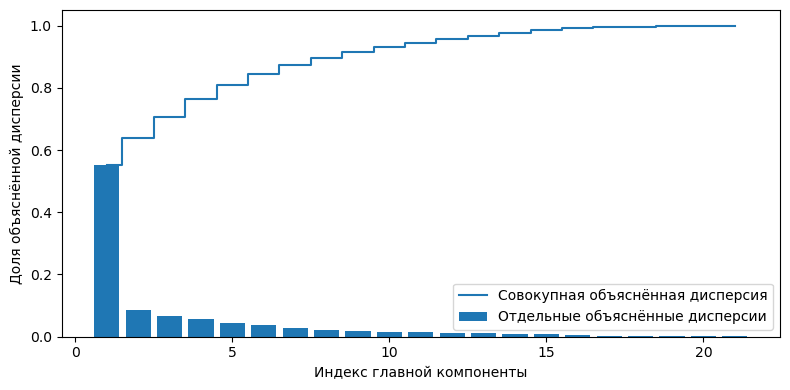

In [50]:
import matplotlib.pyplot as plt
import numpy as np

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,4))
plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1), 
    pca.explained_variance_ratio_, 
    align='center', 
    label='Отдельные объяснённые дисперсии'
)
plt.step(
    range(1, len(pca.explained_variance_ratio_) + 1),
    cum_var,
    where='mid',
    label='Совокупная объяснённая дисперсия'
)
plt.xlabel('Индекс главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Так как первые 5 компонент описывают 80 процентов дисперсии, то рассмотрим их нагрузки

In [51]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

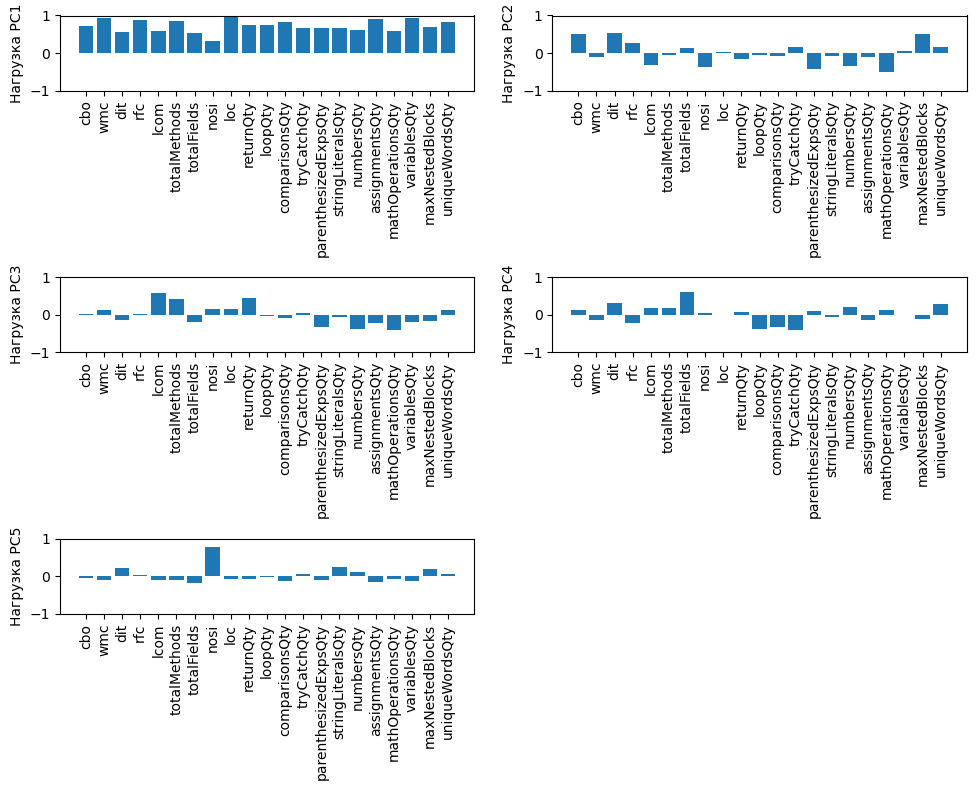

In [65]:
fig, axes = plt.subplots(3, 2, figsize=(10,8))

for i, ax in enumerate(axes.flat):
    if (i < 5):
        ax.bar(range(21), loadings[:, i], align='center')
        ax.set_xticks(range(21))
        ax.set_xticklabels(dataset.columns[:-1], rotation=90)
        ax.set_ylabel(f'Нагрузка PC{i+1}') 
        ax.set_ylim(-1, 1) 
    else:
        ax.axis('off')
plt.ylim(-1,1)
plt.tight_layout()
plt.show()    